# Cross integration: Multiple ADT + ATAC, every method

This notebook runs every method that has a variant for cross Multiple ADT + ATAC on `D58mini`: MOFA2, Multigrate, StabMap, UINMF and scMoMaT. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/cross_adt_atac/) explains each step and runs StabMap and UINMF only.

Methods run on Linux. The environments are 4 envs, 15.9 GB to download on a CPU host, 19.5 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D58mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["MOFA2", "Multigrate", "StabMap", "UINMF", "scMoMaT"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,scmb_r,"[StabMap, UINMF]",have
1,MOFA2_env,[MOFA2],have
2,scmb_multigrate2,[Multigrate],have
3,scmb_torch,[scMoMaT],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D58mini", "cross", methods=METHODS,
                  out_dir="out/D58mini_all")
res.summary

[run_all] 17 more rows need files this folder does not have. mtb.scan shows them.


[run_all] MOFA2 (cross/D58mini) ...


[run_all]   -> CHAIN_OK (29.3s) ARI 0.230


[run_all] Multigrate (cross/D58mini) ...


[run_all]   -> CHAIN_OK (41.9s) ARI 0.244


...

[run_all] UINMF (cross/D58mini) ...


[run_all]   -> CHAIN_OK (21.9s) ARI 0.769


[run_all] scMoMaT (cross/D58mini) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (106.8s) ARI 0.140


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,MOFA2,CHAIN_OK,29.3,embedding,"[3000, 20]",0,cty1.csv+cty2.csv,1.0000,file_of_origin,2,...,0.5053,0.4894,0.8352,0.9967,0.7985,0.9992,0.2335,None,,
1,Multigrate,CHAIN_OK,41.9,embedding,"[3000, 15]",3,cty1.csv+cty2.csv,1.0000,file_of_origin,2,...,0.6634,0.7252,0.8408,1.0000,0.8997,0.9974,0.8105,None,,
2,StabMap,CHAIN_OK,12.3,embedding,"[3000, 50]",0,cty2.csv+cty1.csv,0.9988,file_of_origin,2,...,0.5586,0.5877,0.9284,0.9985,0.8736,0.9973,0.7995,None,,
3,UINMF,CHAIN_OK,21.9,embedding,"[3000, 30]",0,cty1.csv+cty2.csv,1.0000,file_of_origin,2,...,0.6051,0.6294,0.9230,0.9988,0.7890,0.9851,0.8852,None,,
4,scMoMaT,CHAIN_OK_GRAPH_METHOD,106.8,graph,"[3000, 2]",0,cty1.csv+cty2.csv,0.9986,file_of_origin,2,...,0.8484,0.8942,0.7357,1.0000,0.8494,0.9757,0.8562,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

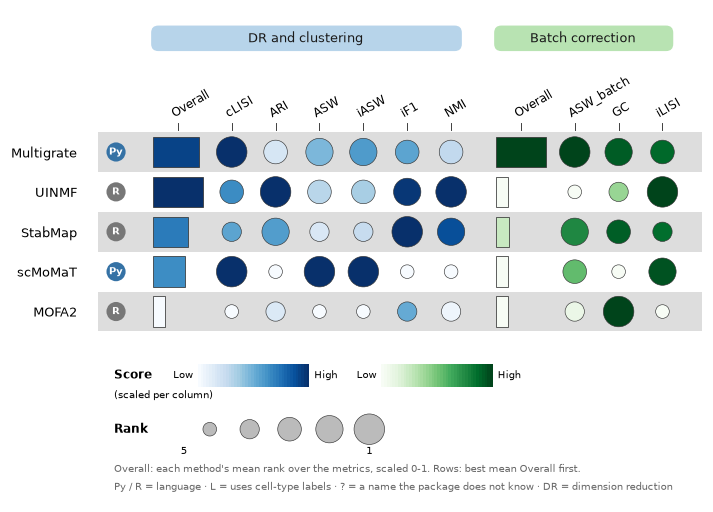

In [5]:
res.plot()